# Kajiado North — Load, Clean, and Initial Analysis
This notebook loads the voter CSV, cleans key fields, filters to the Kajiado North constituency, performs basic QA, and produces summary tables and simple plots.

**Import Libraries**

In [1]:
# Cell 2: Imports and display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
pd.options.display.max_columns = 200
pd.options.display.width = 120

## **Load the Dataset**

In [2]:
# Cell 3: Load raw CSV
DATA_PATH = '034 - 034.csv (1).csv'
# load everything as string first to avoid parsing problems
df_raw = pd.read_csv(DATA_PATH, dtype=str, encoding='utf-8', keep_default_na=False)
print('Rows loaded:', len(df_raw))
print('Columns:', list(df_raw.columns))
df_raw.head()

Rows loaded: 463273
Columns: ['county', 'constituency', 'caw', 'polling_center', 'polling_station', 'pstream', 'date_of_birth', 'fname', 'mname', 'sname', 'sex', 'id_passport_no']


,county,constituency,caw,polling_center,polling_station,pstream,date_of_birth,fname,mname,sname,sex,id_passport_no
0,KAJIADO,KAJIADO WEST,EWUASO OoNKIDONG'I,KIBIKO PRI,KIBIKO PRI,1,01/01/1949,DANIEL,KURIA,KANGACHA,Male,1066762
1,KAJIADO,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,11,06/04/1983,ZACHEAS KAMAU,NULL,JOSEPH,Male,23566512
2,KAJIADO,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,1,01/01/1970,ANNA NJOKI,NULL,KARANJA,Female,9831956
3,KAJIADO,KAJIADO SOUTH,KIMANA,CHRIST THE KING SEC. SCH.,CHRIST THE KING SEC. SCH.,4,01/01/1957,MARY,NJERI,GITAU,Female,370723
4,KAJIADO,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,10,02/01/1984,SIMON MUROKI,NULL,NJOROGE,Male,24000227


### **DataSet Cleaning**

In [3]:
# Cell 4: Cleaning helpers
def clean_text_fields(df):
    text_cols = ['county','constituency','caw','polling_center','polling_station','pstream','sex']
    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace({'NULL':'', 'None':'', 'nan':''}).str.upper()
    return df

def derive_full_name(df):
    for col in ['fname','mname','sname']:
        if col not in df.columns:
            df[col] = ''
    df['full_name'] = (df['fname'].fillna('') + ' ' + df['mname'].fillna('') + ' ' + df['sname'].fillna('')).str.replace('\s+', ' ', regex=True).str.strip()
    return df

def parse_birth_dates(df, reference_year=2026):
    if 'date_of_birth' in df.columns:
        df['birth_date'] = pd.to_datetime(df['date_of_birth'], dayfirst=True, errors='coerce')
        df['birth_year'] = df['birth_date'].dt.year
        df['age'] = np.where(df['birth_year'].notnull(), reference_year - df['birth_year'], np.nan)
    else:
        df['birth_date'] = pd.NaT
        df['birth_year'] = np.nan
        df['age'] = np.nan
    return df


def count_missing(df):
    return df.isin(['', ' ', None, np.nan]).sum()

<>:13: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:13: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\chris\AppData\Local\Temp\ipykernel_9812\1975547982.py:13: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df['full_name'] = (df['fname'].fillna('') + ' ' + df['mname'].fillna('') + ' ' + df['sname'].fillna('')).str.replace('\s+', ' ', regex=True).str.strip()


### **Apply cleaning and Derive Columns**

In [4]:
# **Apply cleaning and derive columns**
df = df_raw.copy()
df = clean_text_fields(df)
df = derive_full_name(df)
df = parse_birth_dates(df)

# Standardize id column name if different
if 'id_passport_no' not in df.columns:
    if 'id' in df.columns:
        df = df.rename(columns={'id':'id_passport_no'})

print('After cleaning — sample:')
df[['constituency','caw','polling_center','polling_station','sex','birth_date','age','full_name']].head()

After cleaning — sample:


,constituency,caw,polling_center,polling_station,sex,birth_date,age,full_name
0,KAJIADO WEST,EWUASO OONKIDONG'I,KIBIKO PRI,KIBIKO PRI,MALE,1949-01-01,77.0,DANIEL KURIA KANGACHA
1,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,MALE,1983-04-06,43.0,ZACHEAS KAMAU NULL JOSEPH
2,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,FEMALE,1970-01-01,56.0,ANNA NJOKI NULL KARANJA
3,KAJIADO SOUTH,KIMANA,CHRIST THE KING SEC. SCH.,CHRIST THE KING SEC. SCH.,FEMALE,1957-01-01,69.0,MARY NJERI GITAU
4,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,MALE,1984-01-02,42.0,SIMON MUROKI NULL NJOROGE


**Filter To Kajiado North Constituency**

In [5]:
# Filter to Kajiado North and quick QA

const_name = 'KAJIADO NORTH'
mask = df['constituency'].fillna('').str.upper() == const_name
df_kn = df[mask].copy()
print('Total records in Kajiado North:', len(df_kn))

# Missing value counts (top fields)
print('\nMissing counts (Kajiado North subset):')
print(count_missing(df_kn)[['date_of_birth','sex','id_passport_no']].to_string())

# Duplicates by id
if 'id_passport_no' in df_kn.columns:
    dup_ids = df_kn['id_passport_no'].duplicated(keep=False)
    print('\nDuplicate id_passport_no count:', dup_ids.sum())

# Age distribution quick stats
print('\nAge stats (Kajiado North):')
print(df_kn['age'].describe())

# Age bands
bins = [0,17,24,34,44,54,64,200]
labels = ['<18','18-24','25-34','35-44','45-54','55-64','65+']
df_kn['age_band'] = pd.cut(df_kn['age'], bins=bins, labels=labels, include_lowest=True)
print('\nAge band counts:')
print(df_kn['age_band'].value_counts().sort_index())

Total records in Kajiado North: 134880

Missing counts (Kajiado North subset):
date_of_birth     0
sex               0
id_passport_no    0

Duplicate id_passport_no count: 58

Age stats (Kajiado North):
count    134880.000000
mean         44.000489
std          12.838737
min          22.000000
25%          35.000000
50%          41.000000
75%          51.000000
max         176.000000
Name: age, dtype: float64

Age band counts:
age_band
<18          0
18-24     1449
25-34    32128
35-44    46868
45-54    29179
55-64    14860
65+      10396
Name: count, dtype: int64


## **Summaries for Sex and CAWs Distribution**

Sex distribution:
 sex
MALE      69864
FEMALE    65016
Name: count, dtype: int64

Top 10 CAWs:
 caw
NKAIMURUNYA      33207
OLKERI           31549
ONGATA RONGAI    27576
NGONG            22738
OLOOLUA          19810
Name: count, dtype: int64


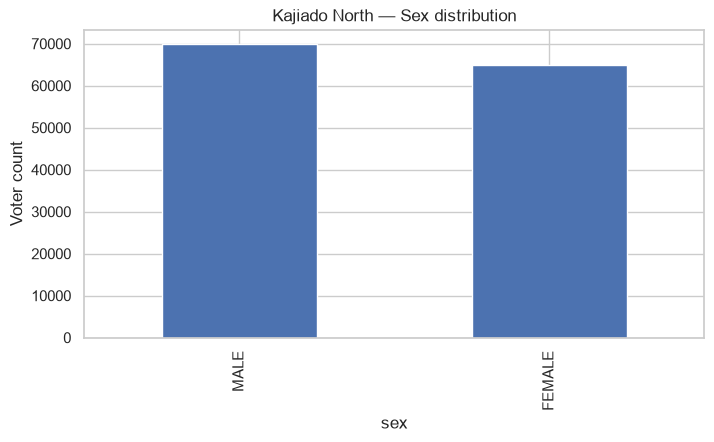

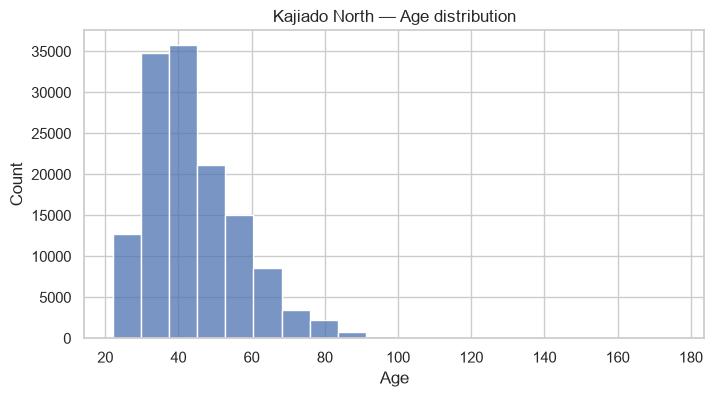

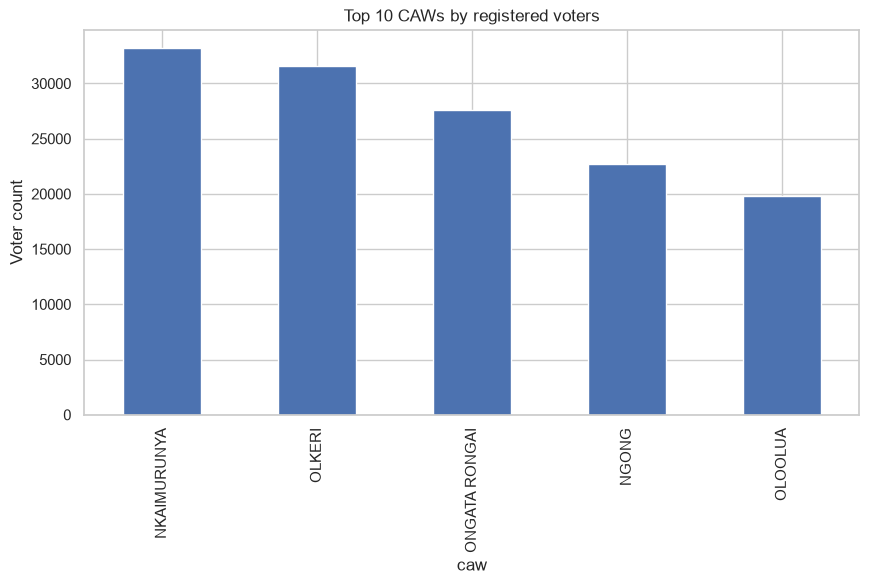

In [6]:
# Summaries and simple plots
# Sex distribution
sex_counts = df_kn['sex'].value_counts(dropna=False)
print('Sex distribution:\n', sex_counts)

# Top CAWs
if 'caw' in df_kn.columns:
    top_caws = df_kn['caw'].value_counts().head(10)
    print('\nTop 10 CAWs:\n', top_caws)

# Plots (safe: only show if non-empty)
plt.figure(figsize=(8,4))
if not sex_counts.empty:
    sex_counts.plot(kind='bar', title='Kajiado North — Sex distribution')
    plt.ylabel('Voter count')
    plt.show()

plt.figure(figsize=(8,4))
if 'age' in df_kn.columns and df_kn['age'].notnull().sum()>0:
    sns.histplot(df_kn['age'].dropna(), bins=20)
    plt.title('Kajiado North — Age distribution')
    plt.xlabel('Age')
    plt.show()

if 'caw' in df_kn.columns and not top_caws.empty:
    plt.figure(figsize=(10,5))
    top_caws.plot(kind='bar')
    plt.title('Top 10 CAWs by registered voters')
    plt.ylabel('Voter count')
    plt.show()

## **Comparative Analysis for Kajiado North vs the rest of Kajiado**

In [7]:
# Analysis continuation: Kajiado North vs rest of Kajiado County
%matplotlib inline
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

DATA_PATH = r"c:\Users\chris\OneDrive\Documents\Kajiado North Voter Analysis\Kajiado_North_Voter_Analysis\034 - 034.csv (1).csv"
OUTPUT_DIR = "analysis_outputs"
REFERENCE_YEAR = 2026
CHUNK_SIZE = 100000
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Ready: ', DATA_PATH)


Ready:  c:\Users\chris\OneDrive\Documents\Kajiado North Voter Analysis\Kajiado_North_Voter_Analysis\034 - 034.csv (1).csv


In [8]:
# Helper functions for cleaning and age derivation
import pandas as pd

def standardize_text(s):
    if pd.isna(s):
        return None
    t = str(s).strip().upper()
    return None if t in ('', 'NULL') else t


def parse_birth_year(dob):
    if pd.isna(dob):
        return None
    dt = pd.to_datetime(dob, dayfirst=True, errors='coerce')
    return int(dt.year) if not pd.isna(dt) else None


def age_from_year(year):
    if year is None:
        return None
    try:
        return REFERENCE_YEAR - int(year)
    except Exception:
        return None


def age_band(age):
    if age is None:
        return 'MISSING'
    age = int(age)
    if age < 18:
        return 'Under 18'
    if 18 <= age <= 24:
        return '18-24'
    if 25 <= age <= 34:
        return '25-34'
    if 35 <= age <= 44:
        return '35-44'
    if 45 <= age <= 54:
        return '45-54'
    if 55 <= age <= 64:
        return '55-64'
    return '65+'

print('Helpers defined')


Helpers defined


In [11]:
# Chunked processing and comparative summaries
cols = ['county','constituency','caw','polling_center','polling_station','pstream',
        'date_of_birth','fname','mname','sname','sex','id_passport_no']

county_tot = 0
north_tot = 0

from collections import Counter
sex_count_county = Counter()
sex_count_north = Counter()

age_counter_county = Counter()
age_counter_north = Counter()

ageband_county = Counter()
ageband_north = Counter()

caw_count_north = Counter()
caw_count_county = Counter()

missing_counts = Counter()

for chunk in pd.read_csv(DATA_PATH, usecols=cols, chunksize=CHUNK_SIZE, dtype=str, encoding='utf-8', low_memory=True):
    for c in ['county','constituency','caw','polling_center','polling_station','pstream','sex']:
        chunk[c] = chunk[c].apply(standardize_text)
    chunk['birth_year'] = chunk['date_of_birth'].apply(parse_birth_year)
    chunk['age'] = chunk['birth_year'].apply(age_from_year)
    chunk['age_band'] = chunk['age'].apply(age_band)

    county_tot += len(chunk)
    for col in cols:
        missing_counts[col] += chunk[col].isna().sum()

    sex_count_county.update(chunk['sex'].fillna('MISSING').tolist())
    for a in chunk['age'].dropna().astype(int).tolist():
        age_counter_county[a] += 1
    ageband_county.update(chunk['age_band'].tolist())
    caw_count_county.update(chunk['caw'].fillna('MISSING').tolist())

    north = chunk[chunk['constituency'] == 'KAJIADO NORTH']
    north_tot += len(north)
    sex_count_north.update(north['sex'].fillna('MISSING').tolist())
    for a in north['age'].dropna().astype(int).tolist():
        age_counter_north[a] += 1
    ageband_north.update(north['age_band'].tolist())
    caw_count_north.update(north['caw'].fillna('MISSING').tolist())



percent_north = north_tot / county_tot * 100 if county_tot else 0.0
print('Totals: county=', county_tot, ' KAJIADO NORTH=', north_tot)
print(f'Kajiado North as % of Kajiado County: {percent_north:.2f}%')


Totals: county= 463273  KAJIADO NORTH= 134880
Kajiado North as % of Kajiado County: 29.11%


,category,count,pct,scope
0,MALE,243125,0.524799,County
1,FEMALE,220148,0.475201,County


,category,count,pct,scope
0,MALE,69864,0.517972,Kajiado North
1,FEMALE,65016,0.482028,Kajiado North


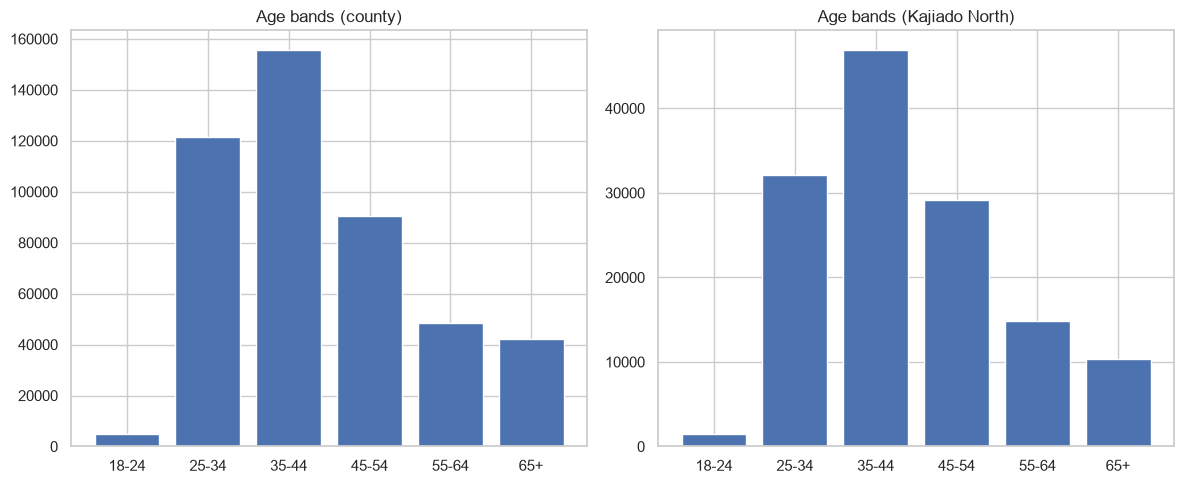

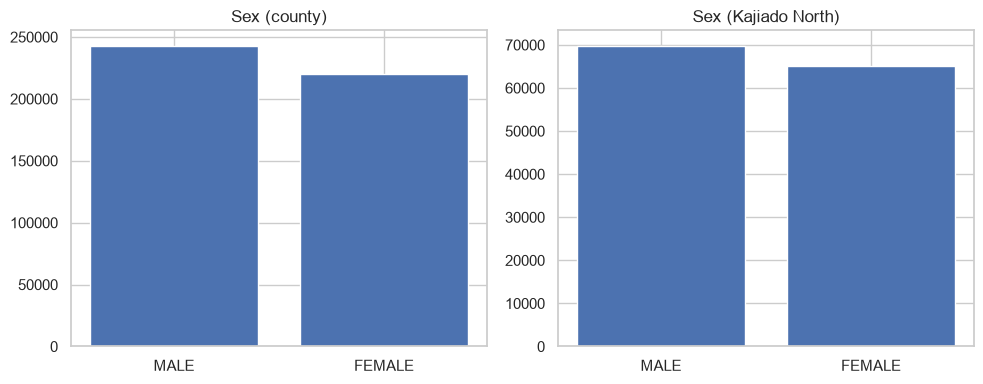

Saved summary to analysis_outputs


In [10]:
# Display sex distribution comparison as DataFrame
def to_df(counter):
    import pandas as _pd
    total = sum(counter.values())
    rows = [{'category':k, 'count':v, 'pct': v/total if total>0 else 0} for k,v in counter.most_common()]
    return _pd.DataFrame(rows)

display(to_df(sex_count_county).assign(scope='County'))
display(to_df(sex_count_north).assign(scope='Kajiado North'))

# Age band comparison plots
fig, ax = plt.subplots(1,2, figsize=(12,5))
keys_c, vals_c = zip(*sorted(ageband_county.items())) if ageband_county else ([],[])
keys_n, vals_n = zip(*sorted(ageband_north.items())) if ageband_north else ([],[])
ax[0].bar(keys_c, vals_c)
ax[0].set_title('Age bands (county)')
ax[1].bar(keys_n, vals_n)
ax[1].set_title('Age bands (Kajiado North)')
plt.tight_layout()
plt.show()

# Sex share plots
fig2, ax2 = plt.subplots(1,2, figsize=(10,4))
kk_c, vv_c = zip(*sex_count_county.most_common()) if sex_count_county else ([],[])
kk_n, vv_n = zip(*sex_count_north.most_common()) if sex_count_north else ([],[])
ax2[0].bar(kk_c, vv_c); ax2[0].set_title('Sex (county)')
ax2[1].bar(kk_n, vv_n); ax2[1].set_title('Sex (Kajiado North)')
plt.tight_layout(); plt.show()

# Save results
with open(os.path.join(OUTPUT_DIR,'analysis_summary.txt'),'w',encoding='utf-8') as f:
    f.write(f'Reference year: {REFERENCE_YEAR}\n')
    f.write(f'Total records (county): {county_tot}\n')
    f.write(f'Total records (Kajiado North): {north_tot}\n')
    f.write('\nSex distribution (county):\n')
    for k,v in sex_count_county.most_common():
        f.write(f'{k}: {v}\n')
    f.write('\nSex distribution (Kajiado North):\n')
    for k,v in sex_count_north.most_common():
        f.write(f'{k}: {v}\n')

print('Saved summary to', OUTPUT_DIR)
